In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

If $A \in \mathbb{R}^{R \times C}$ then its aspect ratio $c = R/C$. So try e.g. $0 < c < 1$. Unscaled, finite-$N$ potential is
$$
V(x) = \frac{x}{2} - \frac{\alpha}{2}\ln(x), \qquad \alpha = C - R + 1 - \frac{2}{\beta},
$$
supported on $[C(1-\sqrt{c})^2, ~ C(1+\sqrt{c})^2]$ Or use the scaled version,
$$
V(x) = \frac{x}{c} - \left(\frac{1}{c} - 1\right)\ln(x),
$$
supported on $[(1-\sqrt{c})^2, ~ (1+\sqrt{c})^2]$. Here $V'(x) = \frac{1}{c} - \frac{\frac{1}{c}-1}{x}$. Because $V$ now has $ln$, need to add a strict positivity check in the metropolis step (unlike the Gaussian ensembles where particles live in the entirety of $\mathbb{R}$).

In [3]:
N = 50; dt = 0.25/(N**(3/2)); beta = 2.0; T = 5.0; 
M = 100; potential_name = "wishart-laguerre"; c = 1/8;
total_steps = int(T/dt);

init = random_matrix.init_wishart_eigenvalues(M, N, c)
wl_pipe = simulate.make_mala_pipeline_wishart(N, dt, potential_name, beta, c)
trajectory = simulate.simulate_dbm(init, total_steps, wl_pipe)

config = {"burn_in": int(2.0/dt), "snapshot_interval": 3, "track_accepts": True}
info = simulate.analyse_trajectory(trajectory, total_steps, **config)

In [ ]:
fig, ax = plt.subplots()

plotters.plot_hist(ax, info["snapshots"], num_bins = 70, potential_name = "wishart-laguerre", c = c)
ax.grid(False)

# plt.savefig("wishart-laguerre-hist-c1eighth.pdf", format = "pdf", dpi = 120)
plt.close()

Mean cross rejects 0.10380031112996747, mean negativity rejects 0.0.


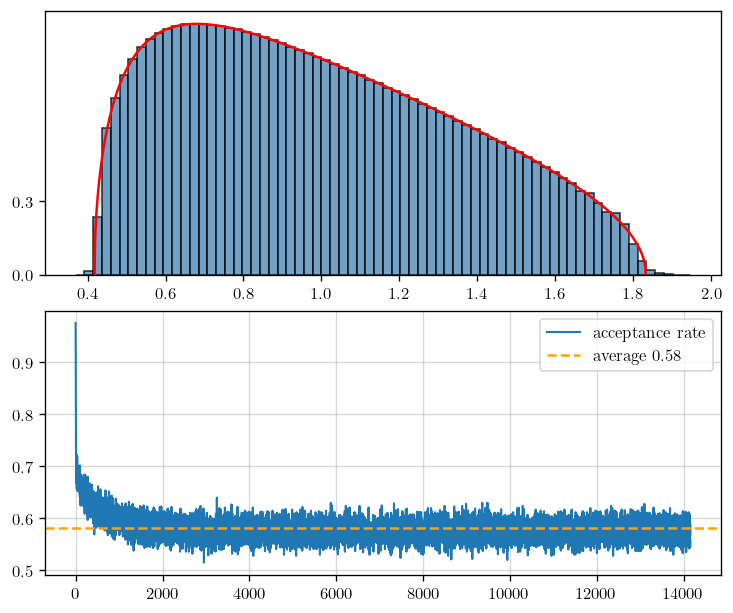

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (6, 5))
ax2, ax3 = axes

plotters.plot_hist(ax2, info["snapshots"], num_bins = 70, potential_name = "wishart-laguerre", c = c)
plotters.plot_accepts(ax3, info["accepts"])
ax2.grid(False)

print(f"Mean cross rejects {info["cross_rejects"].mean()}, mean negativity rejects {info["negativity_rejects"].mean()}.")
plt.show()

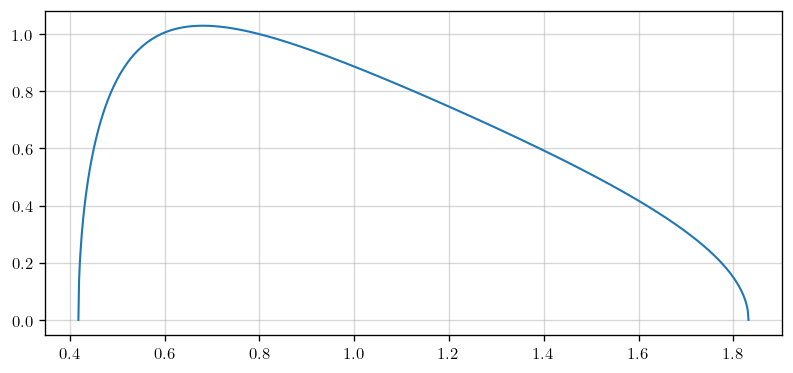